# Customer Churn Analysis - Week 1 EDA
**Author**: [Your Name]
**Date**: [Today's Date]
**Course**: Introduction to Applied AI
## Project Overview
This notebook performs exploratory data analysis on customer churn data to identify
patterns and inform our predictive modeling approach.
## Table of Contents
1. Dataset Overview
2. Numerical Features Analysis
3. Categorical Features Analysis
4. Feature Correlations
5. Key Insights and Findings


In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
# ==============================
# Customer Churn Analysis - Week 1 EDA
# Author: Your Name
# Course: Introduction to Applied AI
# ==============================

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
%matplotlib inline

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Load dataset from Kaggle input folder
df = pd.read_csv('/kaggle/input/datasets/syedafatimazahra123/curundataset/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Dataset Info
df.info()

# Statistical Summary
df.describe()

# Check Missing Values
print("Missing Values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill missing values with median
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

print("Missing values after fixing:")
print(df.isnull().sum())

Missing values after fixing:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


/tmp/ipykernel_55/1729189339.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


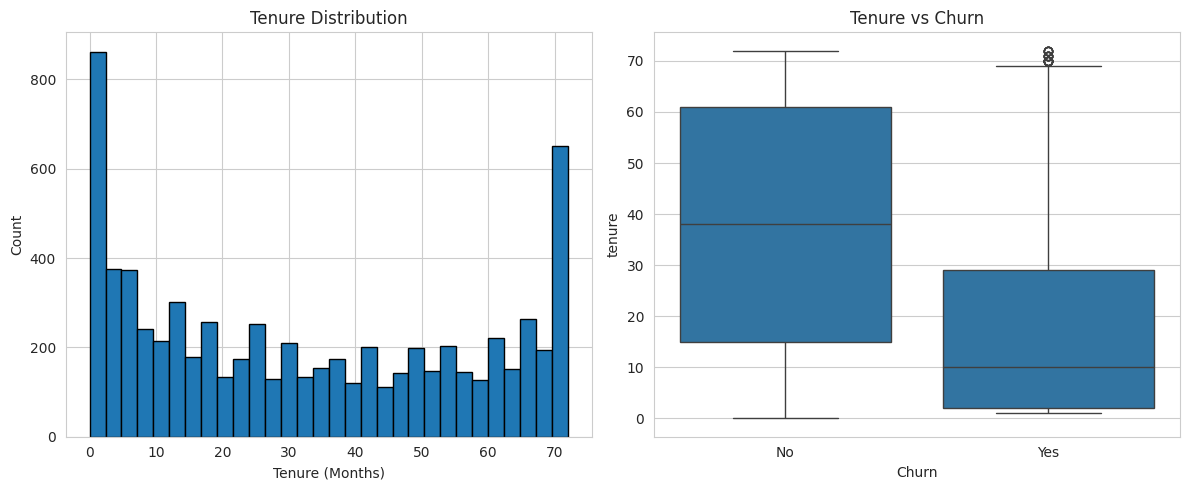

In [6]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(df['tenure'], bins=30, edgecolor='black')
plt.title("Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.ylabel("Count")

plt.subplot(1,2,2)
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure vs Churn")

plt.tight_layout()
plt.show()

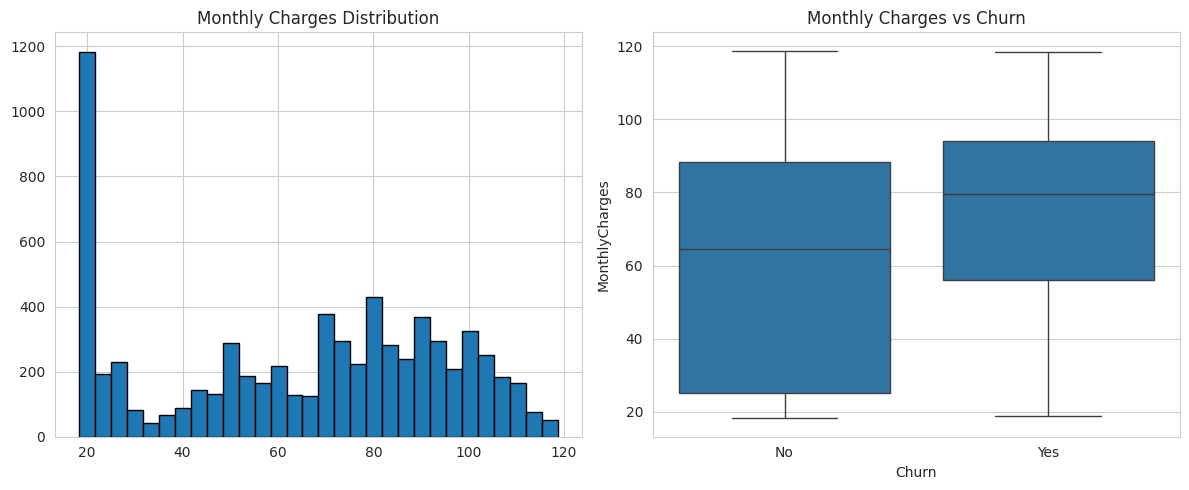

In [9]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(df['MonthlyCharges'], bins=30, edgecolor='black')
plt.title("Monthly Charges Distribution")

plt.subplot(1,2,2)
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")

plt.tight_layout()
plt.show()

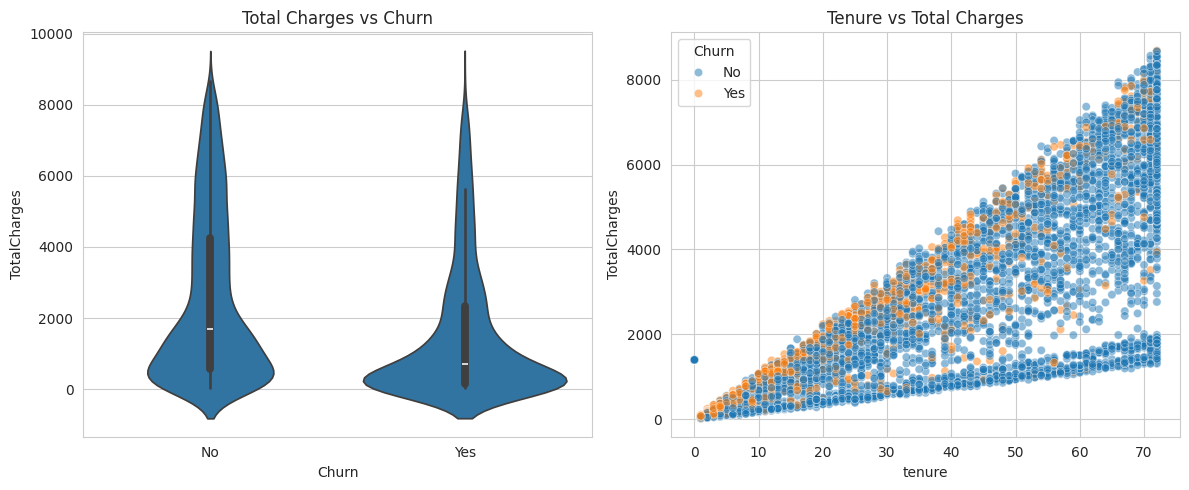

In [10]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.violinplot(x='Churn', y='TotalCharges', data=df)
plt.title("Total Charges vs Churn")

plt.subplot(1,2,2)
sns.scatterplot(x='tenure', y='TotalCharges', hue='Churn', data=df, alpha=0.5)
plt.title("Tenure vs Total Charges")

plt.tight_layout()
plt.show()

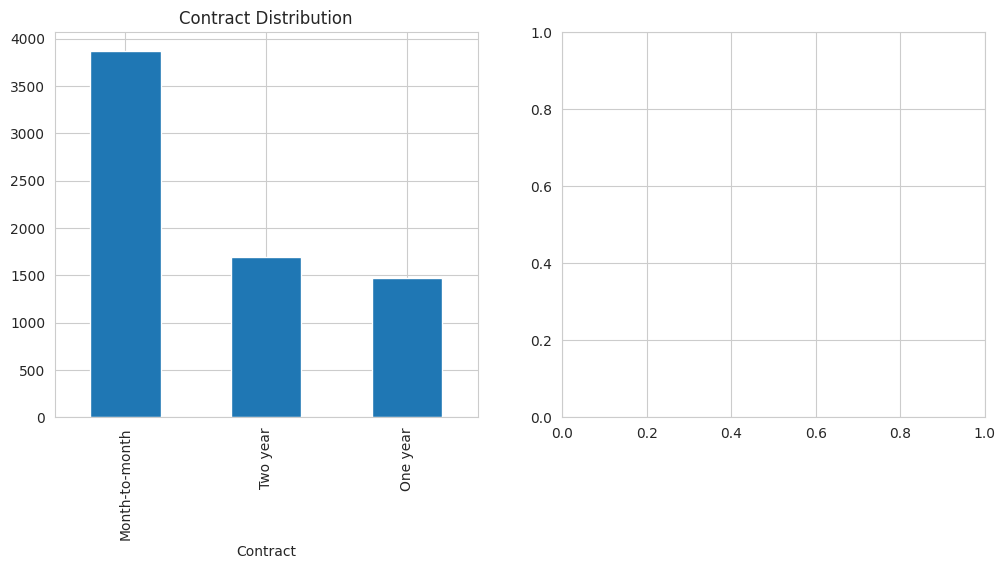

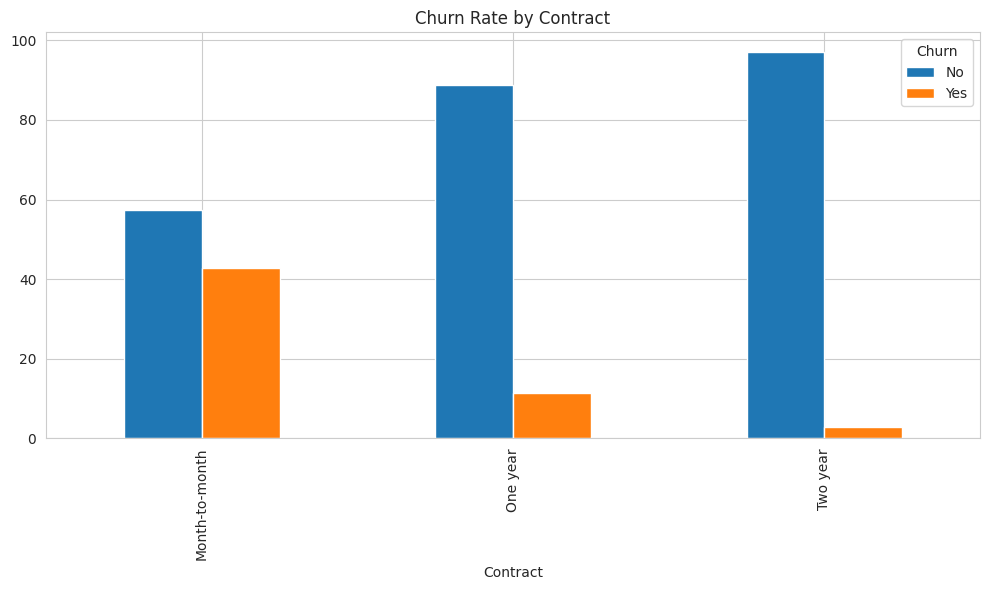

In [11]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
df['Contract'].value_counts().plot(kind='bar')
plt.title("Contract Distribution")

plt.subplot(1,2,2)
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
contract_churn.plot(kind='bar')
plt.title("Churn Rate by Contract")

plt.tight_layout()
plt.show()

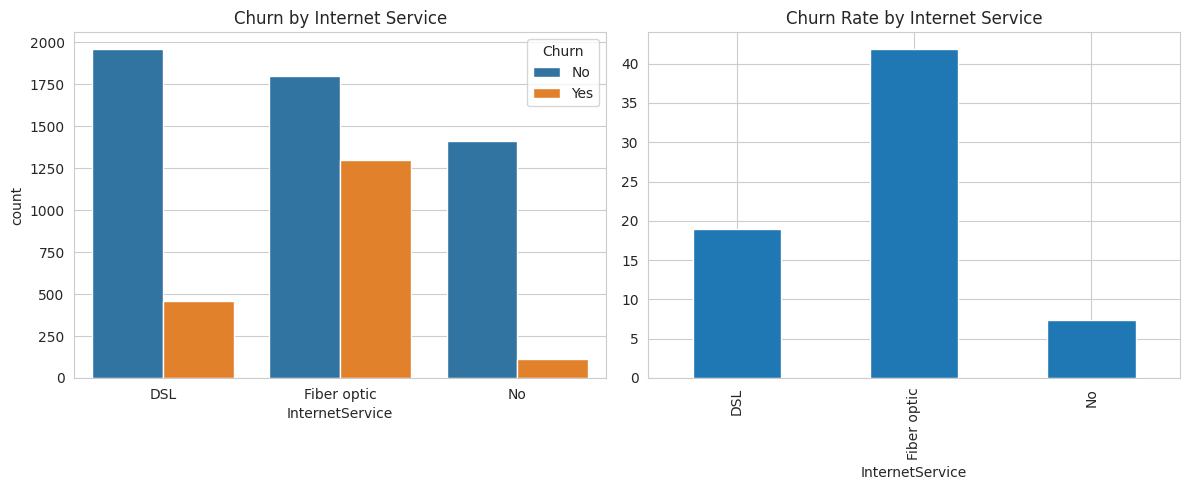

In [12]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title("Churn by Internet Service")

plt.subplot(1,2,2)
internet_churn = pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100
internet_churn['Yes'].plot(kind='bar')
plt.title("Churn Rate by Internet Service")

plt.tight_layout()
plt.show()

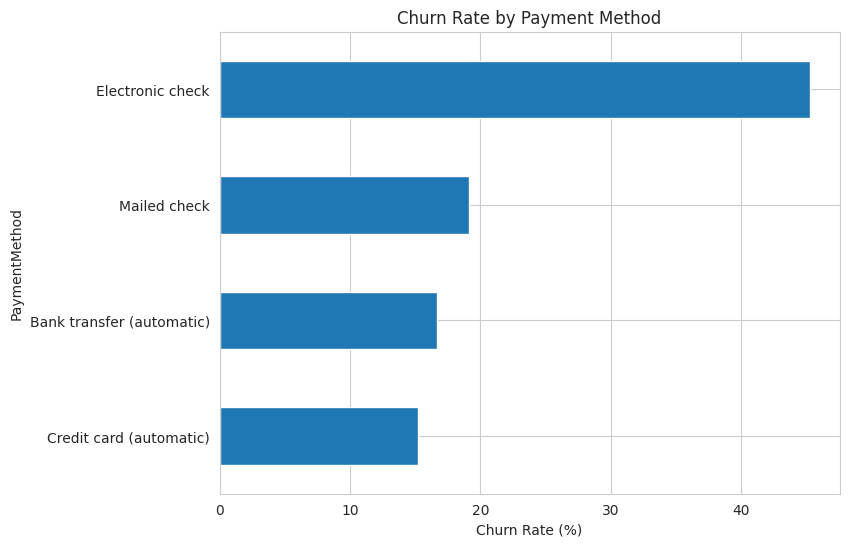

In [13]:
payment_churn = pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index') * 100

plt.figure(figsize=(8,6))
payment_churn['Yes'].sort_values().plot(kind='barh')
plt.title("Churn Rate by Payment Method")
plt.xlabel("Churn Rate (%)")
plt.show()

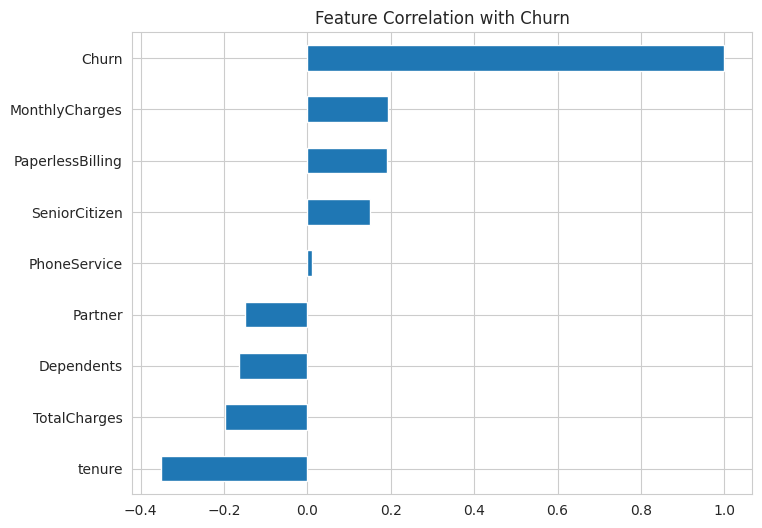

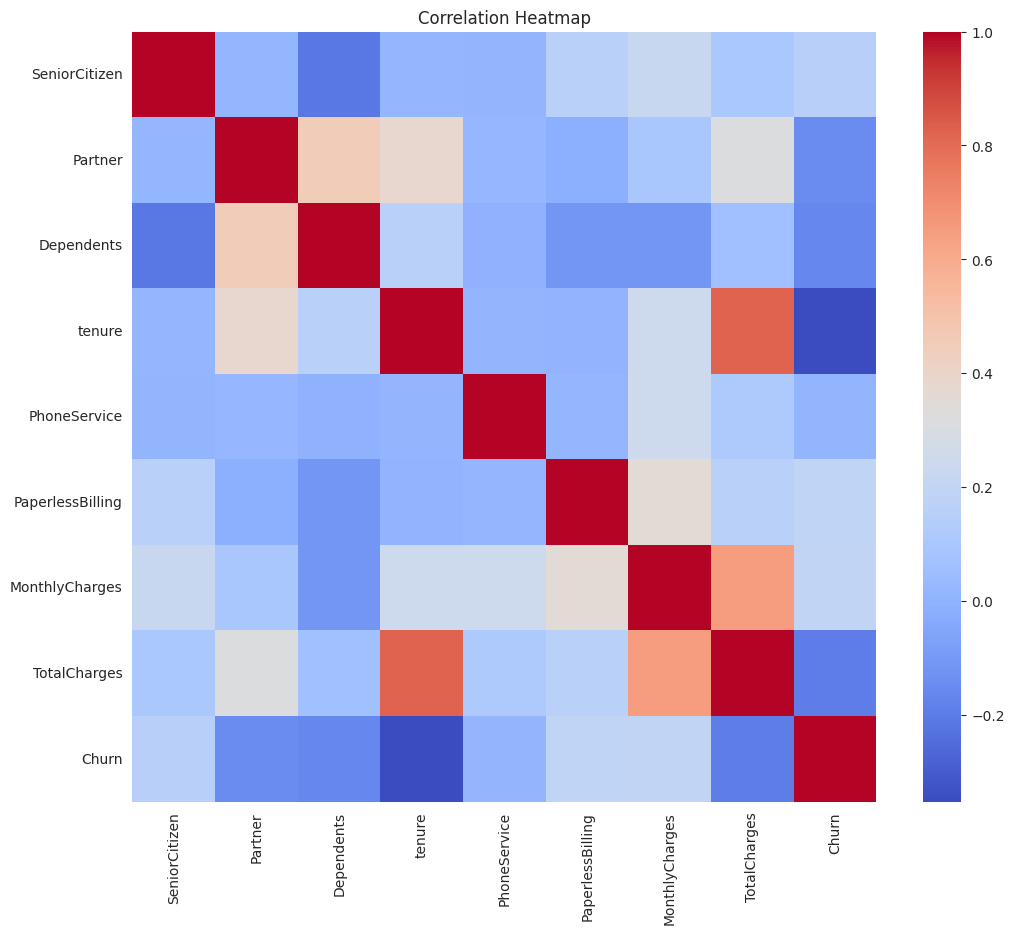

In [14]:
# Convert Yes/No to 1/0
df_numeric = df.copy()

binary_cols = ['Churn', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']

for col in binary_cols:
    if col in df_numeric.columns:
        df_numeric[col] = df_numeric[col].map({'Yes':1, 'No':0})

numeric_features = df_numeric.select_dtypes(include=[np.number])

# Correlation with churn
plt.figure(figsize=(8,6))
numeric_features.corr()['Churn'].sort_values().plot(kind='barh')
plt.title("Feature Correlation with Churn")
plt.show()

# Heatmap
plt.figure(figsize=(12,10))
sns.heatmap(numeric_features.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## Key Insights

1. Month-to-month contract customers have highest churn.
2. Customers with low tenure are more likely to churn.
3. Higher monthly charges increase churn probability.
4. Fiber optic users churn more than DSL.
5. Electronic check users show high churn rate.

## 6. What I Learned Throughout This Lab

During this Week 1 EDA lab, I learned the following important concepts and practical skills:

### 📊 1. Data Loading & Exploration
- How to load real-world datasets using **Pandas**
- How to check dataset shape, columns, and data types using `df.info()`
- How to generate statistical summaries using `df.describe()`
- How to detect and handle missing values properly

### 🧹 2. Data Cleaning
- Converting incorrect data types (e.g., `TotalCharges` to numeric)
- Handling missing values using median replacement
- Understanding why clean data is important before model building

### 📈 3. Exploratory Data Analysis (EDA)
- How to analyze numerical features using:
  - Histograms
  - Boxplots
  - Violin plots
  - Scatter plots
- How to analyze categorical features using:
  - Count plots
  - Bar charts
  - Crosstab analysis

### 🔎 4. Understanding Customer Churn Patterns
- Customers with **month-to-month contracts** are more likely to churn
- Customers with **low tenure** have higher churn probability
- Higher **monthly charges** increase churn risk
- **Fiber optic users** churn more than DSL users
- Certain **payment methods** (like electronic check) show higher churn rates

### 🔗 5. Correlation Analysis
- How to convert categorical Yes/No values into numeric (1/0)
- How to calculate feature correlations
- How to visualize relationships using a correlation heatmap
- Identifying which features are strongly related to churn

### 💡 6. Importance of EDA Before Machine Learning
This lab helped me understand that:
- EDA is the foundation of any machine learning project
- Understanding patterns in data helps in better feature engineering
- Good analysis improves model performance in later stages

### 🚀 Overall Learning Outcome
By completing this lab, I gained confidence in:
- Working with real-world datasets
- Performing structured exploratory data analysis
- Creating meaningful visualizations
- Extracting actionable insights from data

This analysis will help me in Week 2 when building predictive machine learning models.